In [8]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250718-train-ablation',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading results for DMSs: {'SHOC2_HUMAN_Kwon_2022', 'ANCSZ_Hobbs_2022', 'BLAT_ECOLX_Firnberg_2014', 'CBS_HUMAN_Sun_2020', 'HSP82_YEAST_Flynn_2019', 'HXK4_HUMAN_Gersing_2022_activity', 'OXDA_RHOTO_Vanella_2023_activity', 'PPM1D_HUMAN_Miller_2022', 'HEM3_HUMAN_Loggerenberg_2023'}


In [9]:
round_metrics_df.config_name.value_counts()

config_name
FolDE-with-sp-04-01                         540
FolDE-no-zeroShot                           540
FolDE-no-ensemble                           540
FolDE-with-sp-08-0001                       540
FolDE-with-sp-04-00001                      540
FolDE-with-sp-08-01                         540
FolDE-no-MLP                                540
FolDE-no-BTLoss                             540
FolDE-with-sp-04-0001                       540
FolDE-with-sp-02-01                         540
FolDE-with-sp-06-00001                      540
FolDE-with-sp-06-001                        540
FolDE-no-constantliar                       540
FolDE-with-sp-06-01                         540
RandomToRandomForest                        540
FolDE-with-sp-08-00001                      540
FolDE-with-sp-08-001                        540
FolDE-base                                  540
Random                                      540
FolDE-no-naturalnessTraining-or-ensemble    540
FolDE-with-sp-06-0001       

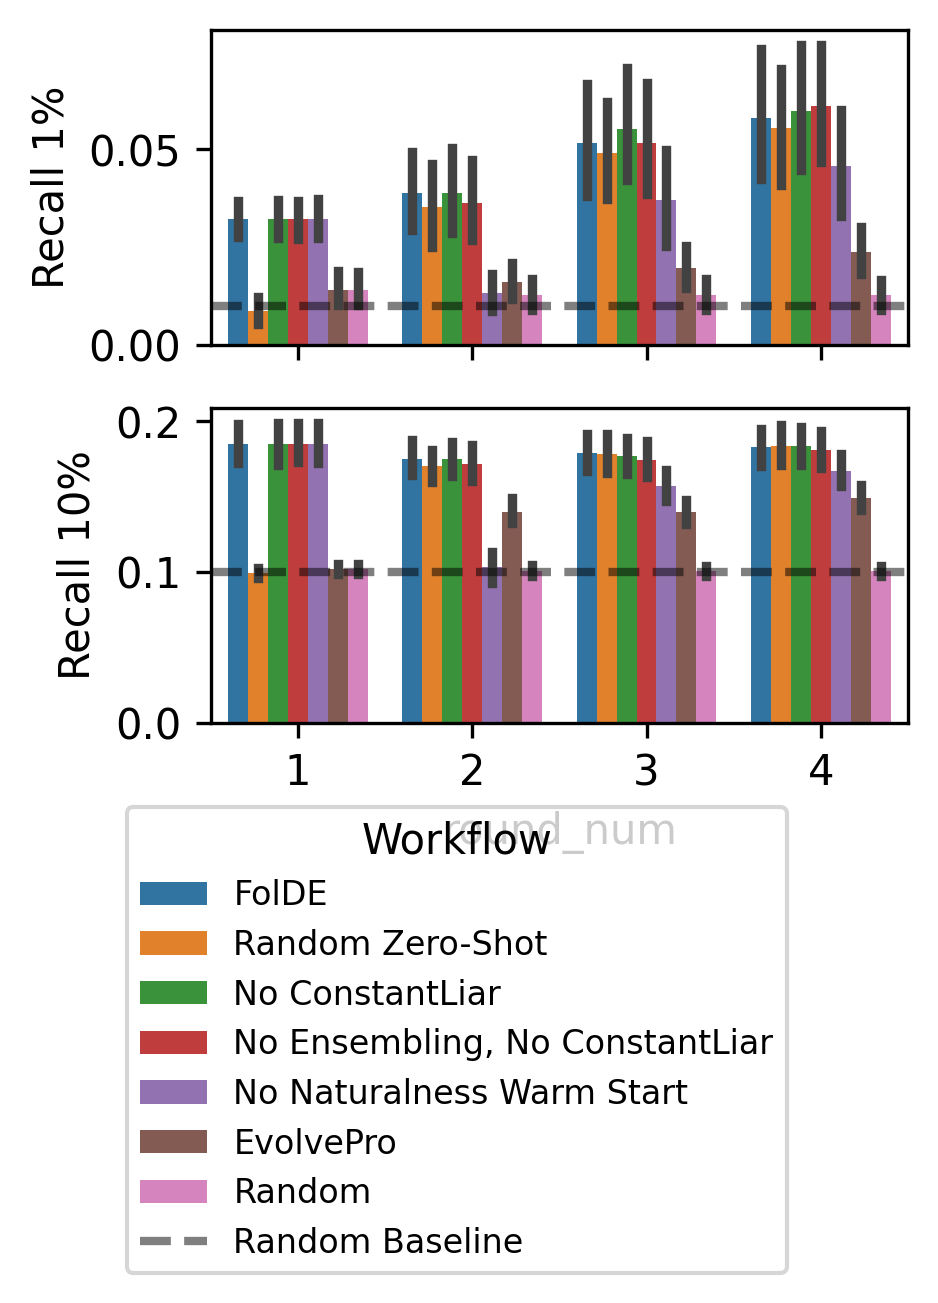

In [18]:
# METRIC = 'held_out_10pct_recall'

configs = [
    ('FolDE-base', 'FolDE'),
    ('FolDE-no-zeroShot', 'Random Zero-Shot'),
    ('FolDE-no-constantliar', 'No ConstantLiar'),
    ('FolDE-no-ensemble', 'No Ensembling, No ConstantLiar'),
    ('FolDE-no-naturalnessTraining', 'No Naturalness Warm Start'),
    ('RandomToRandomForest', 'EvolvePro'),
    ('Random', 'Random'),
    # ('MLP-randomZeroShot-natTraining', 'Random First Round +\nTraining'),
]

plot_df = round_metrics_df.copy()
plot_df['config_name'] = plot_df['config_name'].apply(lambda x: dict(configs).get(x, x))

# plt.figure(figsize=(3, 3), dpi=300)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 3), sharex=True, dpi=300)

for ax, metric in zip([ax1, ax2], [ 'held_out_1pct_recall', 'held_out_10pct_recall']):
    ax = sns.barplot(
        data=plot_df[(plot_df.round_num <= 4) & (plot_df.config_name.isin([c for _, c in configs]))],
        x='round_num',
        y=metric,
        hue='config_name',
        hue_order=[c for _, c in configs],
        ax=ax,
    )

# treatment_matrix = [
#     ['random', 'nat.', 'nat.'],
#     ['-', '-', '+'],
# ]

# row_labels = ['Zero Shot', 'Few Shot: Naturalness Training']
# for i, label in enumerate(row_labels):
#     y = 0.08 - i * 0.015  # control vertical spacing
#     for j, sym in enumerate(treatment_matrix[i]):
#         ax.text(j, y, sym, ha='center', va='top', fontsize=12)
#     # Optional: add row label on the left
#     ax.text(-0.5, y, label, ha='right', va='top', fontsize=12)

# Clean up plot
# ax.set_ylim(0.09, 0.22)
# ax.set_ylabel('Recall 10%, Train Targets')
# ax.spines['bottom'].set_visible(False)
# ax.tick_params(axis='x', length=0)
# ax.set_xticks([])  # hide original x-axis labels if desired

ax1.axhline(y=0.01, color='black', linewidth=2, alpha=0.5, linestyle='--', label='Random Baseline')
ax1.set_ylabel('Recall 1%')

ax2.axhline(y=0.1, color='black', linewidth=2, alpha=0.5, linestyle='--', label='Random Baseline')
ax2.set_ylabel('Recall 10%')

ax1.get_legend().remove()
ax2.legend(
    title='Workflow',
    loc='lower right',
    bbox_to_anchor=(0.85, -1.8),
    fontsize=8
)


/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_19017/2985274245.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_19017/2985274245.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_19017/2985274245.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_19017/2985274245.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

Adding legend


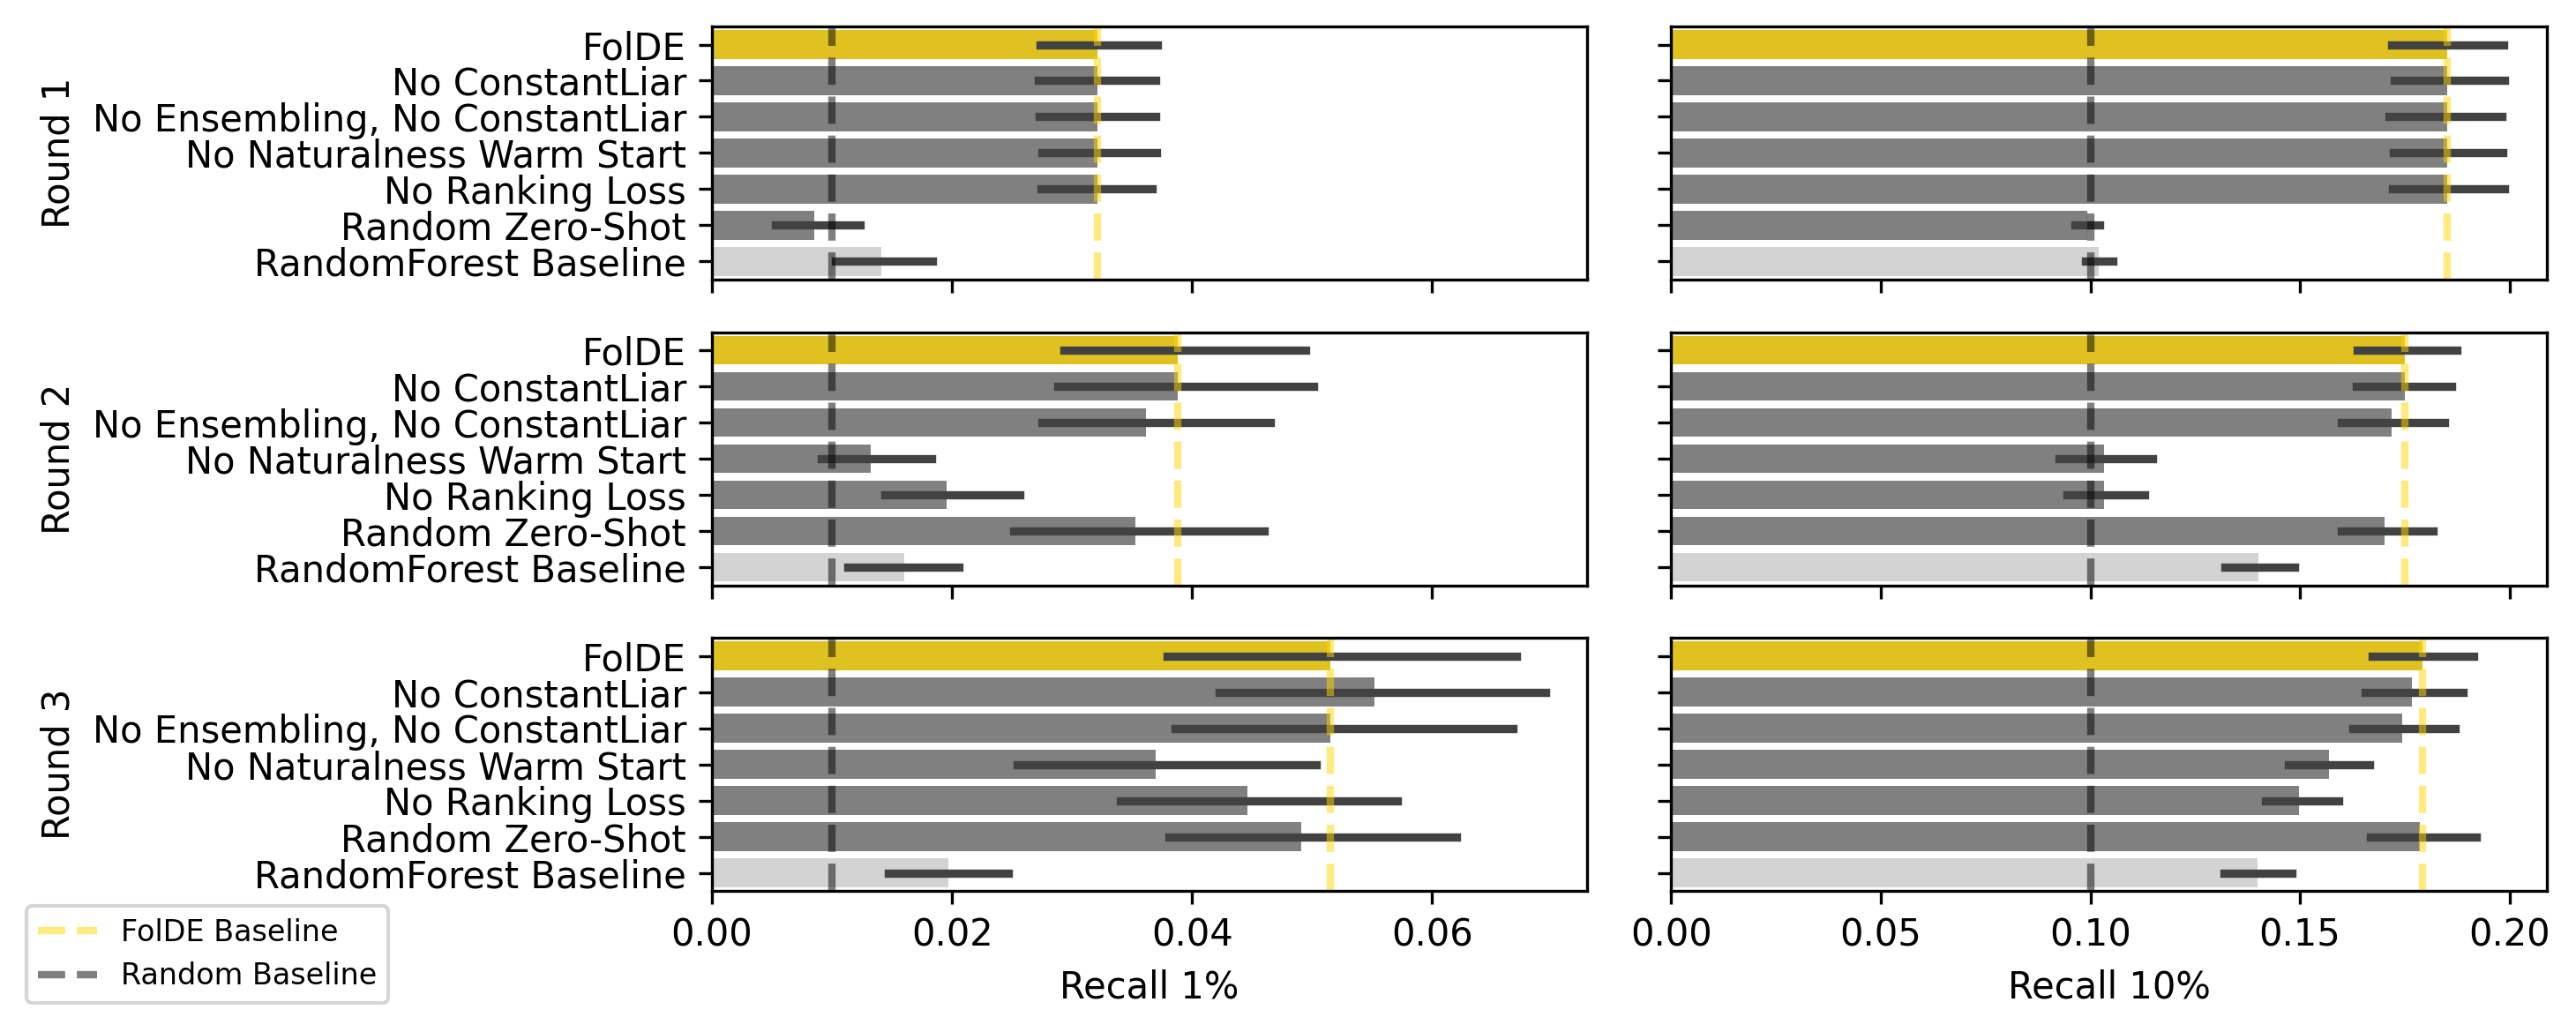

In [59]:
# METRIC = 'held_out_10pct_recall'

N_ROUNDS = 3

configs = [
    ('FolDE-base', 'FolDE'),
    ('FolDE-no-constantliar', 'No ConstantLiar'),
    ('FolDE-no-ensemble', 'No Ensembling, No ConstantLiar'),
    ('FolDE-no-naturalnessTraining', 'No Naturalness Warm Start'),
    ('FolDE-no-BTLoss', 'No Ranking Loss'),
    ('FolDE-no-zeroShot', 'Random Zero-Shot'),
    ('RandomToRandomForest', 'RandomForest Baseline'),
    # ('RandomToRandomForest', 'EvolvePro'),
    # ('Random', 'Random'),
    # ('MLP-randomZeroShot-natTraining', 'Random First Round +\nTraining'),
]

plot_df = round_metrics_df.copy()
plot_df['config_name'] = plot_df['config_name'].apply(lambda x: dict(configs).get(x, x))

# plt.figure(figsize=(3, 3), dpi=300)
fig, axs = plt.subplots(N_ROUNDS, 2, figsize=(10, 4), dpi=300, sharey=True, sharex='col')

for row_idx, row_axs in enumerate(axs):
    for ax, metric in zip(row_axs, ['held_out_1pct_recall', 'held_out_10pct_recall']):
        subplot_df = plot_df[(plot_df.round_num == row_idx + 1) & (plot_df.config_name.isin([c for _, c in configs]))]
        sns.barplot(
            data=subplot_df,
            y='config_name',
            x=metric,
            # hue='round_num',
            order=[c for _, c in configs],
            ax=ax,
            orient='h',  # Explicitly set horizontal orientation
            palette={c[1]: {'FolDE': 'gold', 'RandomForest Baseline': 'lightgrey'}.get(c[1], 'grey') for c in configs}
        )
        ax.axvline(x=subplot_df[subplot_df.config_name == configs[0][1]][metric].mean(), color='gold', linewidth=2, alpha=0.5, linestyle='--', label='FolDE Baseline')

# Clean up legends
for row_idx, row_axs in enumerate(axs):
    for col_idx, ax in enumerate(row_axs):

        # Handle x-axis labels.
        if row_idx == N_ROUNDS - 1:
            if col_idx == 0:
                ax.set_xlabel('Recall 1%')
            else:
                ax.set_xlabel('Recall 10%')
        else:
            ax.set_xlabel('')

        # Handle y-axis labels.
        if col_idx == 0:
            ax.set_ylabel(f'Round {row_idx + 1}')
        else:
            ax.set_ylabel('')

        # Add baseline.
        if col_idx == 0:
            ax.axvline(x=0.01, color='black', linewidth=2, alpha=0.5, linestyle='--', label='Random Baseline')
        else:
            ax.axvline(x=0.1, color='black', linewidth=2, alpha=0.5, linestyle='--', label='Random Baseline')

        # Handle legend.
        if col_idx == 0 and row_idx == N_ROUNDS - 1:
            print('Adding legend')
            ax.legend(
                # title='Workflow',
                loc='center left',
                bbox_to_anchor=(-0.8, -0.25),
                fontsize=8
            )
        # else:
        #     ax.get_legend().remove()

plt.tight_layout()

In [12]:
plot_df[(plot_df.round_num <= 2) & (plot_df.config_name.isin([c for _, c in configs]))]

,dms_id,config_name,sim_num,variant_pool_size,best_activity_this_round,best_percentile_this_round,best_activity_so_far,normalized_best_activity_so_far,best_percentile_so_far,round_num,...,held_out_activity_spearman,held_out_1pct_recall,held_out_1pct_auc,held_out_10pct_recall,held_out_10pct_auc,old_held_out_1pct_recall,old_held_out_1pct_auc,zero_shot_debug_info,few_shot_debug_info,dms_shortname
0,ANCSZ_Hobbs_2022,No ConstantLiar,0,2335,0.065342,0.065342,0.065342,0.431311,0.923340,1,...,0.582335,0.041667,0.642579,0.217949,0.661400,0.041667,0.642579,{'model_type': 'NaturalnessZeroShotModel'},NaN,ANCSZ
1,ANCSZ_Hobbs_2022,No ConstantLiar,0,2335,1.077712,1.077712,1.077712,0.977044,0.999572,2,...,0.551187,0.166667,0.676204,0.175214,0.642626,0.166667,0.676204,NaN,"{'sorts': {'selection_order': ['L616D', 'L616E...",ANCSZ
0,ANCSZ_Hobbs_2022,No ConstantLiar,1,2335,0.108814,0.108814,0.108814,0.454745,0.967024,1,...,0.569890,0.041667,0.609621,0.183761,0.640785,0.041667,0.609621,{'model_type': 'NaturalnessZeroShotModel'},NaN,ANCSZ
1,ANCSZ_Hobbs_2022,No ConstantLiar,1,2335,0.138110,0.138110,0.138110,0.470537,0.978158,2,...,0.517259,0.000000,0.614723,0.128205,0.637427,0.000000,0.614723,NaN,"{'sorts': {'selection_order': ['K378F', 'Q571K...",ANCSZ
0,ANCSZ_Hobbs_2022,No ConstantLiar,2,2335,0.108814,0.108814,0.108814,0.454745,0.973876,1,...,0.540080,0.041667,0.641488,0.170940,0.622021,0.041667,0.641488,{'model_type': 'NaturalnessZeroShotModel'},NaN,ANCSZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,SHOC2_HUMAN_Kwon_2022,No Naturalness Warm Start,7,5486,0.665223,0.665223,0.665223,0.567393,0.961356,2,...,0.216941,0.018182,0.651794,0.147541,0.588330,0.018182,0.651794,NaN,"{'sorts': {'selection_order': ['Y358C', 'D275C...",SHOC2_HUMAN
0,SHOC2_HUMAN_Kwon_2022,No Naturalness Warm Start,8,5486,0.706788,0.706788,0.706788,0.571865,0.966825,1,...,0.315343,0.072727,0.743906,0.145719,0.618219,0.072727,0.743906,{'model_type': 'NaturalnessZeroShotModel'},NaN,SHOC2_HUMAN
1,SHOC2_HUMAN_Kwon_2022,No Naturalness Warm Start,8,5486,0.630069,0.630069,0.706788,0.571865,0.966825,2,...,-0.017289,0.036364,0.546864,0.096539,0.501871,0.036364,0.546864,NaN,"{'sorts': {'selection_order': ['D175R', 'E25I'...",SHOC2_HUMAN
0,SHOC2_HUMAN_Kwon_2022,No Naturalness Warm Start,9,5486,0.706788,0.706788,0.706788,0.571865,0.968283,1,...,0.320558,0.054545,0.701811,0.123862,0.618912,0.054545,0.701811,{'model_type': 'NaturalnessZeroShotModel'},NaN,SHOC2_HUMAN
